<a href="https://colab.research.google.com/github/BialaStrzala/Sztuczna-Inteligencja-Paula-Grzebyk-21236/blob/main/SI_klasyfikacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paula Grzebyk 21236
**Klasyfikacja**

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import cv2

In [2]:
#zaladowanie datasetow
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']
#wyodrebnienie zestawu walidacyjnego -> sprawdza model podczas nauki (przed koncowym testem),
#blokuje przetrenowanie
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.OZ9C16_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.OZ9C16_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [3]:
#normalizacja danych
def scale(image, label):
  #wejscia 0-255 -> 0-1
  image = tf.cast(image, tf.float32)
  image /= 255.
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

#partie treningowe
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [4]:
input_size = 784 #28x28px
output_size = 10 #10 cyfr
hidden_layer_size = 50

model = tf.keras.Sequential([
    #warstwa wejsciowa 28x28x1 px
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    #warstwy posrednie
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    #warstwa wyjsciowa
    tf.keras.layers.Dense(output_size, activation='softmax'),
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
NUM_EPOCHS = 30 #epoki

#chroni przed przetrenowaniem modelu
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose=1)

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8832 - loss: 0.4121 - val_accuracy: 0.9355 - val_loss: 0.2206
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9478 - loss: 0.1819 - val_accuracy: 0.9488 - val_loss: 0.1662
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9608 - loss: 0.1382 - val_accuracy: 0.9582 - val_loss: 0.1418
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9672 - loss: 0.1122 - val_accuracy: 0.9610 - val_loss: 0.1321
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9720 - loss: 0.0956 - val_accuracy: 0.9623 - val_loss: 0.1253
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9759 - loss: 0.0832 - val_accuracy: 0.9628 - val_loss: 0.1248
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9793 - loss: 0.0715 - val_accuracy: 0.9610 - val_loss: 0.1272
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9809 - loss: 0.0642 - val_accuracy: 0

In [6]:
#sprawdzenie modelu
test_loss, test_accuracy = model.evaluate(test_data)
print('Loss: {0:.2f}, accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step - accuracy: 0.9648 - loss: 0.1143
Loss: 0.11, accuracy: 96.48%


Loss: 0.11, accuracy: 96.48%

# Zadanie

(28, 28, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Probabilities for first sample: [2.61493940e-02 6.53757452e-05 1.20520745e-04 2.92836368e-01
 2.74230644e-07 6.80117369e-01 1.24637954e-04 3.58057041e-05
 5.50220837e-04 4.93013239e-08]
Predicted class index for first sample: 5


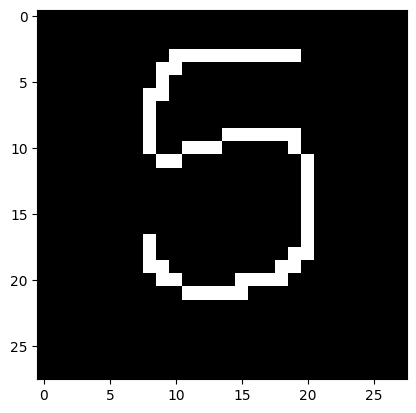

In [34]:
from matplotlib import pyplot
imgname = 'obraz.png'
image = cv2.imread(imgname)
print(image.shape)
pyplot.imshow(image)

from PIL import Image
from skimage import transform
def load(filename):
   np_image = Image.open(filename)
   np_image = np.array(np_image).astype('float32')/255
   np_image = transform.resize(np_image, (28, 28, 1))
   np_image = np.expand_dims(np_image, axis=0)
   return np_image

image = load(imgname)

probabilities_multi = model.predict(image)
predicted_class_indices = np.argmax(probabilities_multi, axis=1)
print(f"Probabilities for first sample: {probabilities_multi[0]}")
print(f"Predicted class index for first sample: {predicted_class_indices[0]}")


**Dla cyfry '6' (obraz png 28x28px):**

Probabilities for first sample: [5.83354663e-03 1.87343153e-06 1.13370887e-04 4.96139983e-04
 1.16096762e-05 1.22594565e-01 7.95915425e-01 2.12120128e-07
 7.50332698e-02 3.56507179e-08]

Predicted class index for first sample: **6**



---


**Dla cyfry '8':**

Probabilities for first sample: [9.6675921e-03 5.5531043e-05 2.1814024e-03 2.3797719e-01 8.0533093e-05
 3.1258714e-01 5.1702311e-05 1.4026701e-07 4.3739140e-01 7.3635151e-06]

Predicted class index for first sample: **8**


---

**Dla cyfry '3':**

Predicted class index for first sample: 3

---

**Dla cyfry '5':**

Predicted class index for first sample: 5